In [88]:
import numpy as np
import pandas as pd
import polars as pl

import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import RandomOverSampler

import warnings
warnings.filterwarnings("ignore")

In [89]:
path = r"../data/raw/data.csv"

In [90]:
df = pl.read_csv(path)

In [91]:
df.describe()

statistic,,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
str,f64,f64,str,f64,f64,f64,f64,str,str,f64,f64,f64,f64
"""count""",100.0,100.0,"""100""",100.0,100.0,100.0,100.0,"""100""","""100""",100.0,100.0,100.0,100.0
"""null_count""",0.0,0.0,"""0""",0.0,0.0,0.0,0.0,"""0""","""0""",0.0,0.0,0.0,0.0
"""mean""",173213.17,173214.17,null,41.48,0.99,25.87,0.53,null,null,30657.92,103.46,152.49,0.09
"""std""",108749.026482,108749.026482,null,16.614148,0.1,12.668784,0.501614,null,null,16574.599124,57.05755,83.456091,0.287623
"""min""",63.0,64.0,"""Female""",20.0,0.0,2.0,0.0,"""1-2 Year""","""No""",2630.0,3.0,13.0,0.0
"""25%""",79230.0,79231.0,null,25.0,1.0,15.0,0.0,null,null,24759.0,26.0,83.0,0.0
"""50%""",188161.0,188162.0,null,41.0,1.0,28.0,1.0,null,null,32224.0,124.0,152.0,0.0
"""75%""",257328.0,257329.0,null,51.0,1.0,34.0,1.0,null,null,40849.0,152.0,218.0,0.0
"""max""",358728.0,358729.0,"""Male""",79.0,1.0,51.0,1.0,"""> 2 Years""","""Yes""",67595.0,160.0,293.0,1.0


In [92]:
df.schema

Schema([('', Int64),
        ('id', Int64),
        ('Gender', String),
        ('Age', Int64),
        ('Driving_License', Int64),
        ('Region_Code', Float64),
        ('Previously_Insured', Int64),
        ('Vehicle_Age', String),
        ('Vehicle_Damage', String),
        ('Annual_Premium', Float64),
        ('Policy_Sales_Channel', Float64),
        ('Vintage', Int64),
        ('Response', Int64)])

In [93]:
df.null_count()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,0,0,0,0,0


In [94]:
df['Response'].value_counts()

Response,count
i64,u32
0,91
1,9


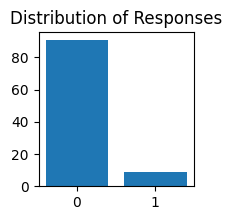

In [95]:
value_count_df = df['Response'].value_counts()

plt.figure(figsize=(2,2))
plt.bar(
    value_count_df['Response'],
    value_count_df['count']
)
plt.title("Distribution of Responses")
plt.show()

In [96]:
df['Age'].hist(bins=20)

breakpoint,category,count
f64,cat,u32


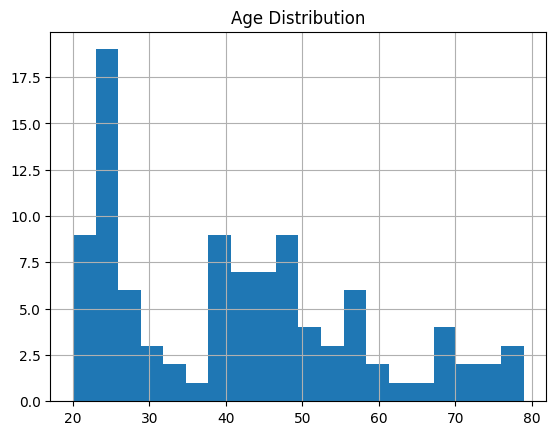

In [97]:
df['Age'].to_pandas().hist(bins=20)
plt.title("Age Distribution")
plt.show()

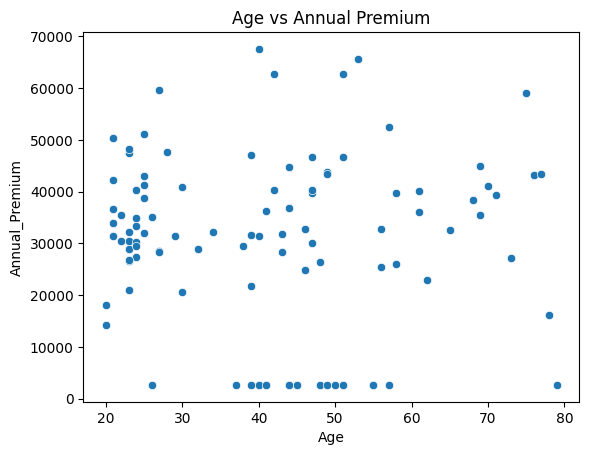

In [98]:
sns.scatterplot(x='Age', y='Annual_Premium', data=df)
plt.title("Age vs Annual Premium")
plt.show()

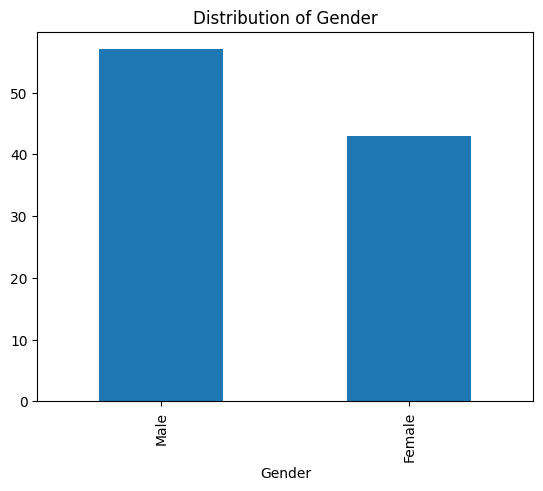

In [99]:
df['Gender'].to_pandas().value_counts().plot(kind='bar')
plt.title("Distribution of Gender")
plt.show()

In [100]:
df[['Gender', 'Response']]

Gender,Response
str,i64
"""Female""",0
"""Male""",1
"""Male""",0
"""Male""",0
"""Male""",0
…,…
"""Female""",0
"""Male""",0
"""Male""",0


In [101]:
data = (
    df.group_by(['Vehicle_Age', 'Response'])
    .agg(pl.count('id').alias('count'))
)

data

Vehicle_Age,Response,count
str,i64,u32
"""> 2 Years""",0,4
"""1-2 Year""",1,7
"""> 2 Years""",1,1
"""< 1 Year""",1,1
"""< 1 Year""",0,36
"""1-2 Year""",0,51


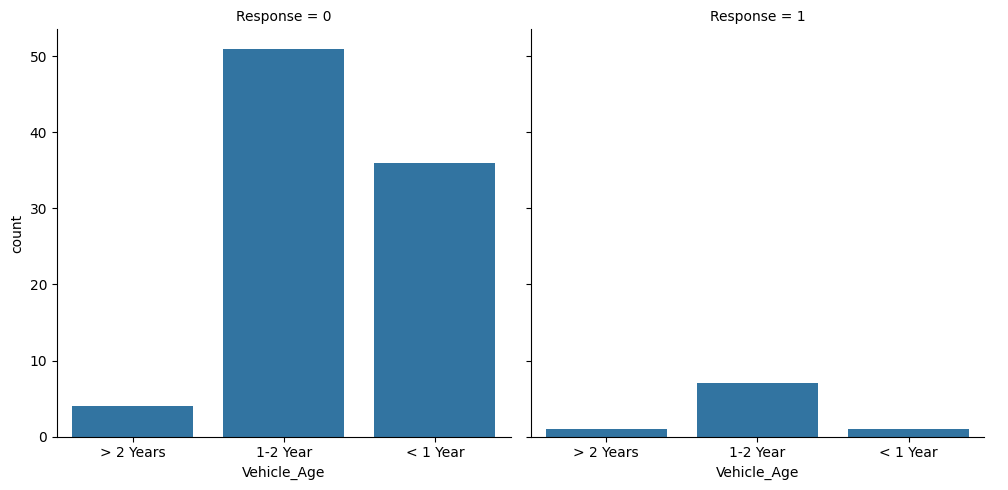

In [102]:
g = sns.catplot(
    x="Vehicle_Age",
    y="count",
    col="Response",
    data=data,
    kind="bar"
)

plt.show()

In [103]:
data = (
    df.group_by(['Gender','Response'])
    .agg(pl.count('id').alias('count'))
)

data

Gender,Response,count
str,i64,u32
"""Male""",1,7
"""Male""",0,50
"""Female""",1,2
"""Female""",0,41


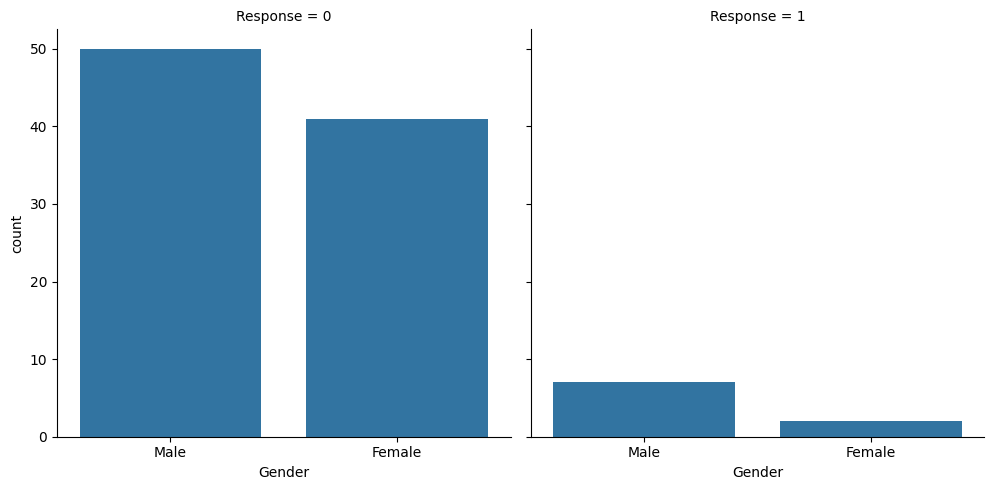

In [104]:
g = sns.catplot(
    x="Gender",
    y="count",
    col="Response",
    data=data,
    kind="bar"
)

plt.show()

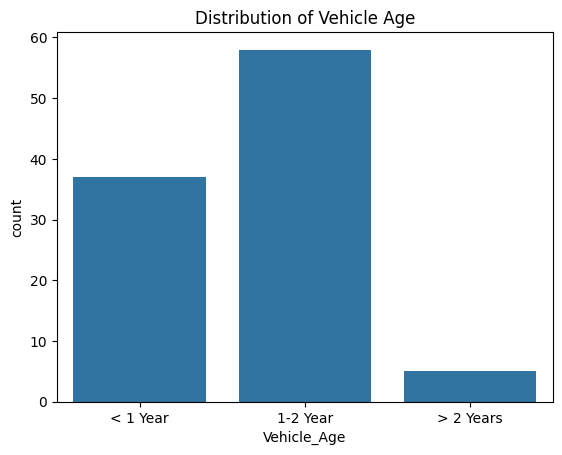

In [105]:
sns.countplot(x='Vehicle_Age', data=df)
plt.title("Distribution of Vehicle Age")
plt.show()

# Data Processing

In [106]:
num_feat = ['Age','Vintage']
cat_feat = ['Gender', 'Driving_License', 'Previously_Insured', 'Vehicle_Age_lt_1_Year',
'Vehicle_Age_gt_2_Years','Vehicle_Damage_Yes','Region_Code','Policy_Sales_Channel']

In [107]:
df = df.with_columns(
    df['Gender'].replace({'Female':0, 'Male': 1}).cast(pl.Int64)
)

In [108]:
df = df.to_dummies(cat_feat, drop_first=True)
df.head(2)

,id,Gender_1,Age,Driving_License_0,Region_Code_11.0,Region_Code_12.0,Region_Code_13.0,Region_Code_14.0,Region_Code_15.0,Region_Code_17.0,Region_Code_18.0,Region_Code_19.0,Region_Code_2.0,Region_Code_20.0,Region_Code_21.0,Region_Code_22.0,Region_Code_24.0,Region_Code_26.0,Region_Code_27.0,Region_Code_28.0,Region_Code_29.0,Region_Code_3.0,Region_Code_30.0,Region_Code_31.0,Region_Code_32.0,Region_Code_33.0,Region_Code_34.0,Region_Code_35.0,Region_Code_36.0,Region_Code_37.0,Region_Code_38.0,Region_Code_39.0,Region_Code_40.0,Region_Code_41.0,Region_Code_45.0,Region_Code_46.0,Region_Code_47.0,Region_Code_5.0,Region_Code_50.0,Region_Code_51.0,Region_Code_6.0,Region_Code_8.0,Region_Code_9.0,Previously_Insured_0,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel_12.0,Policy_Sales_Channel_122.0,Policy_Sales_Channel_124.0,Policy_Sales_Channel_14.0,Policy_Sales_Channel_147.0,Policy_Sales_Channel_151.0,Policy_Sales_Channel_152.0,Policy_Sales_Channel_156.0,Policy_Sales_Channel_157.0,Policy_Sales_Channel_160.0,Policy_Sales_Channel_25.0,Policy_Sales_Channel_3.0,Policy_Sales_Channel_52.0,Policy_Sales_Channel_66.0,Vintage,Response
i64,i64,u8,i64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,str,str,f64,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,u8,i64,i64
257328,257329,0,23,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,"""< 1 Year""","""No""",28893.0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,191,0
248819,248820,1,48,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,"""1-2 Year""","""Yes""",2630.0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,97,1


In [109]:
df.collect_schema()

Schema([('', Int64),
        ('id', Int64),
        ('Gender_1', UInt8),
        ('Age', Int64),
        ('Driving_License_0', UInt8),
        ('Region_Code_11.0', UInt8),
        ('Region_Code_12.0', UInt8),
        ('Region_Code_13.0', UInt8),
        ('Region_Code_14.0', UInt8),
        ('Region_Code_15.0', UInt8),
        ('Region_Code_17.0', UInt8),
        ('Region_Code_18.0', UInt8),
        ('Region_Code_19.0', UInt8),
        ('Region_Code_2.0', UInt8),
        ('Region_Code_20.0', UInt8),
        ('Region_Code_21.0', UInt8),
        ('Region_Code_22.0', UInt8),
        ('Region_Code_24.0', UInt8),
        ('Region_Code_26.0', UInt8),
        ('Region_Code_27.0', UInt8),
        ('Region_Code_28.0', UInt8),
        ('Region_Code_29.0', UInt8),
        ('Region_Code_3.0', UInt8),
        ('Region_Code_30.0', UInt8),
        ('Region_Code_31.0', UInt8),
        ('Region_Code_32.0', UInt8),
        ('Region_Code_33.0', UInt8),
        ('Region_Code_34.0', UInt8),
        ('Region

In [110]:
col_rename = {
    "Vehicle_Age_< 1 Year": "Vehicle_Age_lt_1_Year",
    "Vehicle_Age_> 2 Years": "Vehicle_Age_gt_2_Years"
}

df.rename(col_rename)

ColumnNotFoundError: "Vehicle_Age_< 1 Year" not found